<div style="display:block;width:100%;margin:auto;" direction=rtl align=center><br><br>
    <div  style="width:100%;margin:100;display:block;background-color:#fff0;"  display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">             <tr>
                <td  style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>Armin Ghasemi</b><br><br>810100198</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> ML </b><br><br>Final_Project</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>  </b><br><br></i></font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
           </tr>
        </table>
    </div>
</div>

# 🚻 Gender Classification: A Comparative Study
### From SVMs to Deep Neural Networks (PyTorch)

> **University:** University of Tehran
> **Course:** Machine Learning
> **Project:** Final Capstone Project - Part C
> **Task:** Binary Classification (Male vs. Female)

---

## 🎯 Objective
In this notebook, we train and evaluate multiple supervised learning models to classify the gender of a speaker based on extracted audio features (MFCCs, Pitch, ZCR). We compare traditional statistical models (**Logistic Regression, KNN, SVM**) against a deep learning approach (**Multi-Layer Perceptron using PyTorch**).

## ⚙️ Workflow
1.  **Data Cleaning:** Handling duplicates, missing values, and outlier imputation.
2.  **EDA:** Visualizing feature distributions for Male vs. Female classes.
3.  **Feature Selection:** Using ANOVA (Filter method) and Random Forest Importance (Wrapper method) to select the most discriminative features.
4.  **Scaling:** Comparing Standardization (Z-score) vs. Normalization (MinMax).
5.  **Modeling:** Training 4 distinct classifiers and evaluating them using ROC/AUC and Confusion Matrices.

### Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, roc_curve, auc, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler, MinMaxScaler, label_binarize
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# Global Path Configuration
# ==========================================
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "data", "feature_stores")

# Define input filenames (Ensure these match your actual filenames)
TRAIN_FILENAME = "gender_train.csv"  
TEST_FILENAME = "gender_test.csv"  

TRAIN_PATH = os.path.join(DATA_DIR, TRAIN_FILENAME)
TEST_PATH = os.path.join(DATA_DIR, TEST_FILENAME)

print(f"Training data path: {TRAIN_PATH}")
print(f"Test data path: {TEST_PATH}")
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch using device: {device}")

### Data loading, preprocessing and splitting

In [ ]:
# --- 1. Load Data ---
if os.path.exists(TRAIN_PATH) and os.path.exists(TEST_PATH):
    train_df = pd.read_csv(TRAIN_PATH)
    test_df = pd.read_csv(TEST_PATH)
    print("Datasets loaded successfully.")
else:
    raise FileNotFoundError("Train or Test CSV files not found in 'data/feature_stores'.")

# --- 2. Data Cleaning ---
# Handle Duplicates
duplicates_train = train_df.duplicated().sum()
if duplicates_train > 0:
    print(f"{duplicates_train} duplicates removed from train set.")
    train_df.drop_duplicates(inplace=True)

duplicates_test = test_df.duplicated().sum()
if duplicates_test > 0:
    print(f"{duplicates_test} duplicates removed from test set.")
    test_df.drop_duplicates(inplace=True)

# Handle Missing Values
if train_df.isnull().sum().sum() > 0:
    print("Dropping missing values in train set...")
    train_df.dropna(inplace=True)

if test_df.isnull().sum().sum() > 0:
    print("Dropping missing values in test set...")
    test_df.dropna(inplace=True)

# --- 3. Split Features & Target ---
# Assuming 'Gender' column exists and is the target
target_col = "Gender"

if target_col in train_df.columns:
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]
    X_test = test_df.drop(columns=[target_col])
    y_test = test_df[target_col]
    
    # Remove 'filename' if it exists (it's not a feature)
    if "filename" in X_train.columns:
        X_train = X_train.drop(columns=["filename"])
        X_test = X_test.drop(columns=["filename"])
        
    print(f"Data Splitting Complete.")
    print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")
else:
    raise ValueError(f"Target column '{target_col}' not found in dataset.")

## Exploratory Data Analysis (EDA)
Visualizing the distribution of features to understand separability. We plot histograms for each feature, colored by class (Male/Female), to see which features distinguish the genders best (e.g., Pitch/F0 usually shows clear separation).

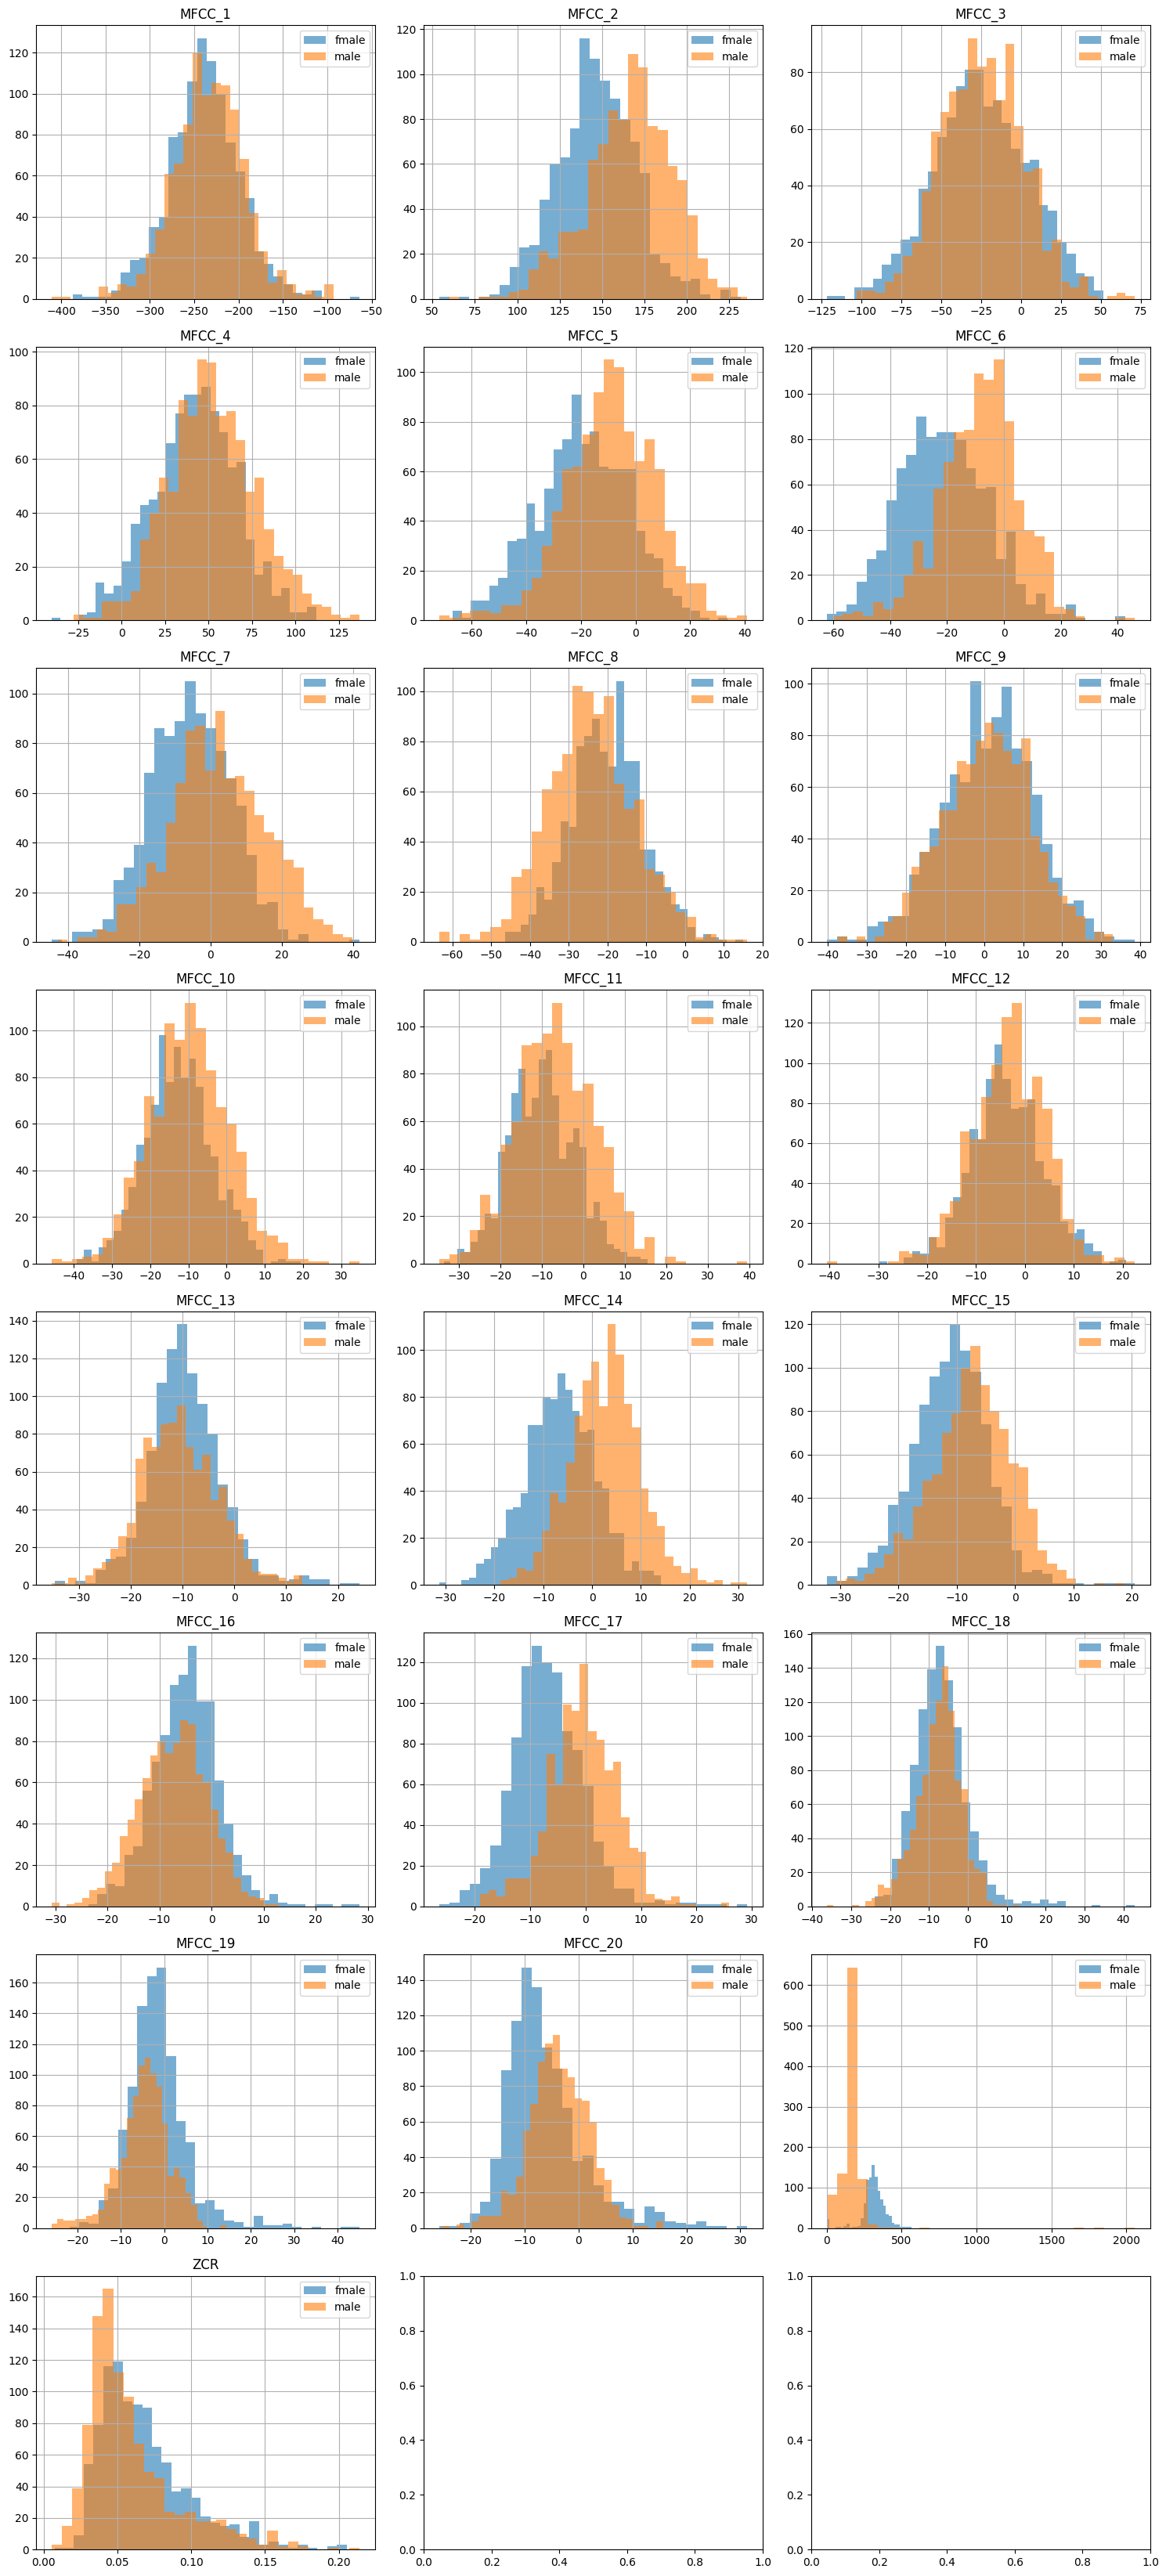

In [3]:
X_train["Gender"] = y_train.values  

num_features = X_train.shape[1] - 1 
fig, axes = plt.subplots(nrows=num_features // 3 + 1, ncols=3, figsize=(15, num_features * 1.5))
axes = axes.flatten()

for i, col in enumerate(X_train.columns[:-1]):  
    X_train[X_train["Gender"] == 0][col].hist(alpha=0.6, bins=30, label="fmale", ax=axes[i])
    X_train[X_train["Gender"] == 1][col].hist(alpha=0.6, bins=30, label="male", ax=axes[i])
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

X_train = X_train.drop(columns=["Gender"])


## Advanced Preprocessing: Outlier Handling
Instead of simply deleting data points that fall outside the Interquartile Range (IQR), we employ a **Linear Regression Imputation** strategy. This preserves the dataset size while correcting anomalous values based on correlations with other features.

In [4]:
def count_outliers(data):
    outlier_counts = {}
    for column in data.columns:
        Q1 = data[column].quantile(0.25)
        Q3 = data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outlier_counts[column] = ((data[column] < lower_bound) | (data[column] > upper_bound)).sum()
    return outlier_counts

outliers_indices = []
for column in X_train.columns:
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    column_outliers = X_train[(X_train[column] < lower_bound) | (X_train[column] > upper_bound)].index
    outliers_indices.extend(column_outliers)

outliers_indices = list(set(outliers_indices))

X_train_cleaned = X_train.copy()
for column in X_train.columns:
    column_outliers = X_train_cleaned.loc[outliers_indices, column]
    if not column_outliers.empty:
        other_columns = [col for col in X_train.columns if col != column]
        model = LinearRegression()
        non_outliers = X_train_cleaned.drop(index=outliers_indices)
        model.fit(non_outliers[other_columns], non_outliers[column])
        predicted_values = model.predict(X_train_cleaned.loc[outliers_indices, other_columns])
        X_train_cleaned.loc[outliers_indices, column] = predicted_values

outliers_before = count_outliers(X_train)
outliers_after = count_outliers(X_train_cleaned)

outliers_summary = pd.DataFrame({
    'Column': X_train.columns,
    'Outliers Before': [outliers_before[col] for col in X_train.columns],
    'Outliers After': [outliers_after[col] for col in X_train.columns]
})
outliers_summary.style.set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
])


,Column,Outliers Before,Outliers After
0,MFCC_1,43,22
1,MFCC_2,11,11
2,MFCC_3,12,9
3,MFCC_4,19,19
4,MFCC_5,15,15
5,MFCC_6,7,7
6,MFCC_7,18,17
7,MFCC_8,26,26
8,MFCC_9,12,12
9,MFCC_10,28,28


## Feature Selection
To reduce overfitting and improve computational efficiency, we apply a two-step feature selection process:
1.  **Filter Method (ANOVA):** Ranking features based on statistical significance (`f_classif`).
2.  **Embedded Method (Random Forest):** Selecting features based on Gini impurity reduction.

### ANOVA Score 

In [5]:
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train_cleaned, y_train)

feature_scores = pd.DataFrame({'Feature': X_train_cleaned.columns, 'Score': selector.scores_})
feature_scores = feature_scores.sort_values(by='Score', ascending=False)
print(feature_scores)


    Feature        Score
20       F0  2541.228799
13  MFCC_14   816.660599
16  MFCC_17   503.445610
5    MFCC_6   361.892492
1    MFCC_2   317.362895
6    MFCC_7   199.585912
4    MFCC_5   181.435452
14  MFCC_15   149.222505
18  MFCC_19   125.307153
19  MFCC_20   120.750117
3    MFCC_4    84.661671
15  MFCC_16    79.556807
7    MFCC_8    78.017084
21      ZCR    71.230515
10  MFCC_11    70.092917
9   MFCC_10    38.887550
12  MFCC_13    18.420472
17  MFCC_18     5.604712
0    MFCC_1     4.465550
8    MFCC_9     1.157273
11  MFCC_12     0.459058
2    MFCC_3     0.158019


In [6]:
selected_features = feature_scores.iloc[:-5]['Feature'].tolist()
X_train_cleaned = X_train_cleaned[selected_features]
X_test = X_test[selected_features]

### Random Forest

In [7]:

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_cleaned, y_train)

rf_importances = rf_model.feature_importances_
feature_rf = pd.DataFrame({'Feature': X_train_cleaned.columns, 'RandomForest_Importance': rf_importances})
feature_rf = feature_rf.sort_values(by='RandomForest_Importance', ascending=False)

print(feature_rf)

    Feature  RandomForest_Importance
0        F0                 0.465079
1   MFCC_14                 0.101059
2   MFCC_17                 0.071562
4    MFCC_2                 0.051930
3    MFCC_6                 0.049176
6    MFCC_5                 0.030630
8   MFCC_19                 0.029906
9   MFCC_20                 0.024094
12   MFCC_8                 0.023624
11  MFCC_16                 0.023350
10   MFCC_4                 0.022752
5    MFCC_7                 0.020093
16  MFCC_13                 0.019883
7   MFCC_15                 0.018726
13      ZCR                 0.016985
14  MFCC_11                 0.016502
15  MFCC_10                 0.014649


In [8]:
selected_features = feature_rf.iloc[:-5]['Feature'].tolist()
X_train_cleaned= X_train_cleaned[selected_features]
X_test = X_test[selected_features]

## Feature Scaling
We generate two versions of the dataset to suit different algorithms:
* **Standardization (Z-Score):** Preferred for SVM and Logistic Regression.
* **Normalization (Min-Max):** Often useful for Neural Networks to bound inputs between 0 and 1.

In [9]:
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

X_train_standardized = pd.DataFrame(scaler_standard.fit_transform(X_train_cleaned), columns=X_train_cleaned.columns)
X_train_normalized = pd.DataFrame(scaler_minmax.fit_transform(X_train_cleaned), columns=X_train_cleaned.columns)

X_test_standardized = pd.DataFrame(scaler_standard.transform(X_test), columns=X_test.columns)
X_test_normalized = pd.DataFrame(scaler_minmax.transform(X_test), columns=X_test.columns)

standardized_data = {
    'X_train_standardized': X_train_standardized,
    'X_test_standardized': X_test_standardized
}

normalized_data = {
    'X_train_normalized': X_train_normalized,
    'X_test_normalized': X_test_normalized
}
print(f"X_train_cleaned:{X_train_cleaned.shape}")
print(f"y_train:{y_train.shape}")
print(f"X_test:{X_test.shape}")
print(f"y_test:{y_test.shape}")
print(f"X_train_standardized:{X_train_standardized.shape}")
print(f"X_test_standardized:{X_test_standardized.shape}")
print(f"X_train_normalized:{X_train_normalized.shape}")
print(f"X_test_normalized:{X_test_normalized.shape}")

X_train_cleaned:(2000, 12)
y_train:(2000,)
X_test:(360, 12)
y_test:(360,)
X_train_standardized:(2000, 12)
X_test_standardized:(360, 12)
X_train_normalized:(2000, 12)
X_test_normalized:(360, 12)


### Plotting standardized data

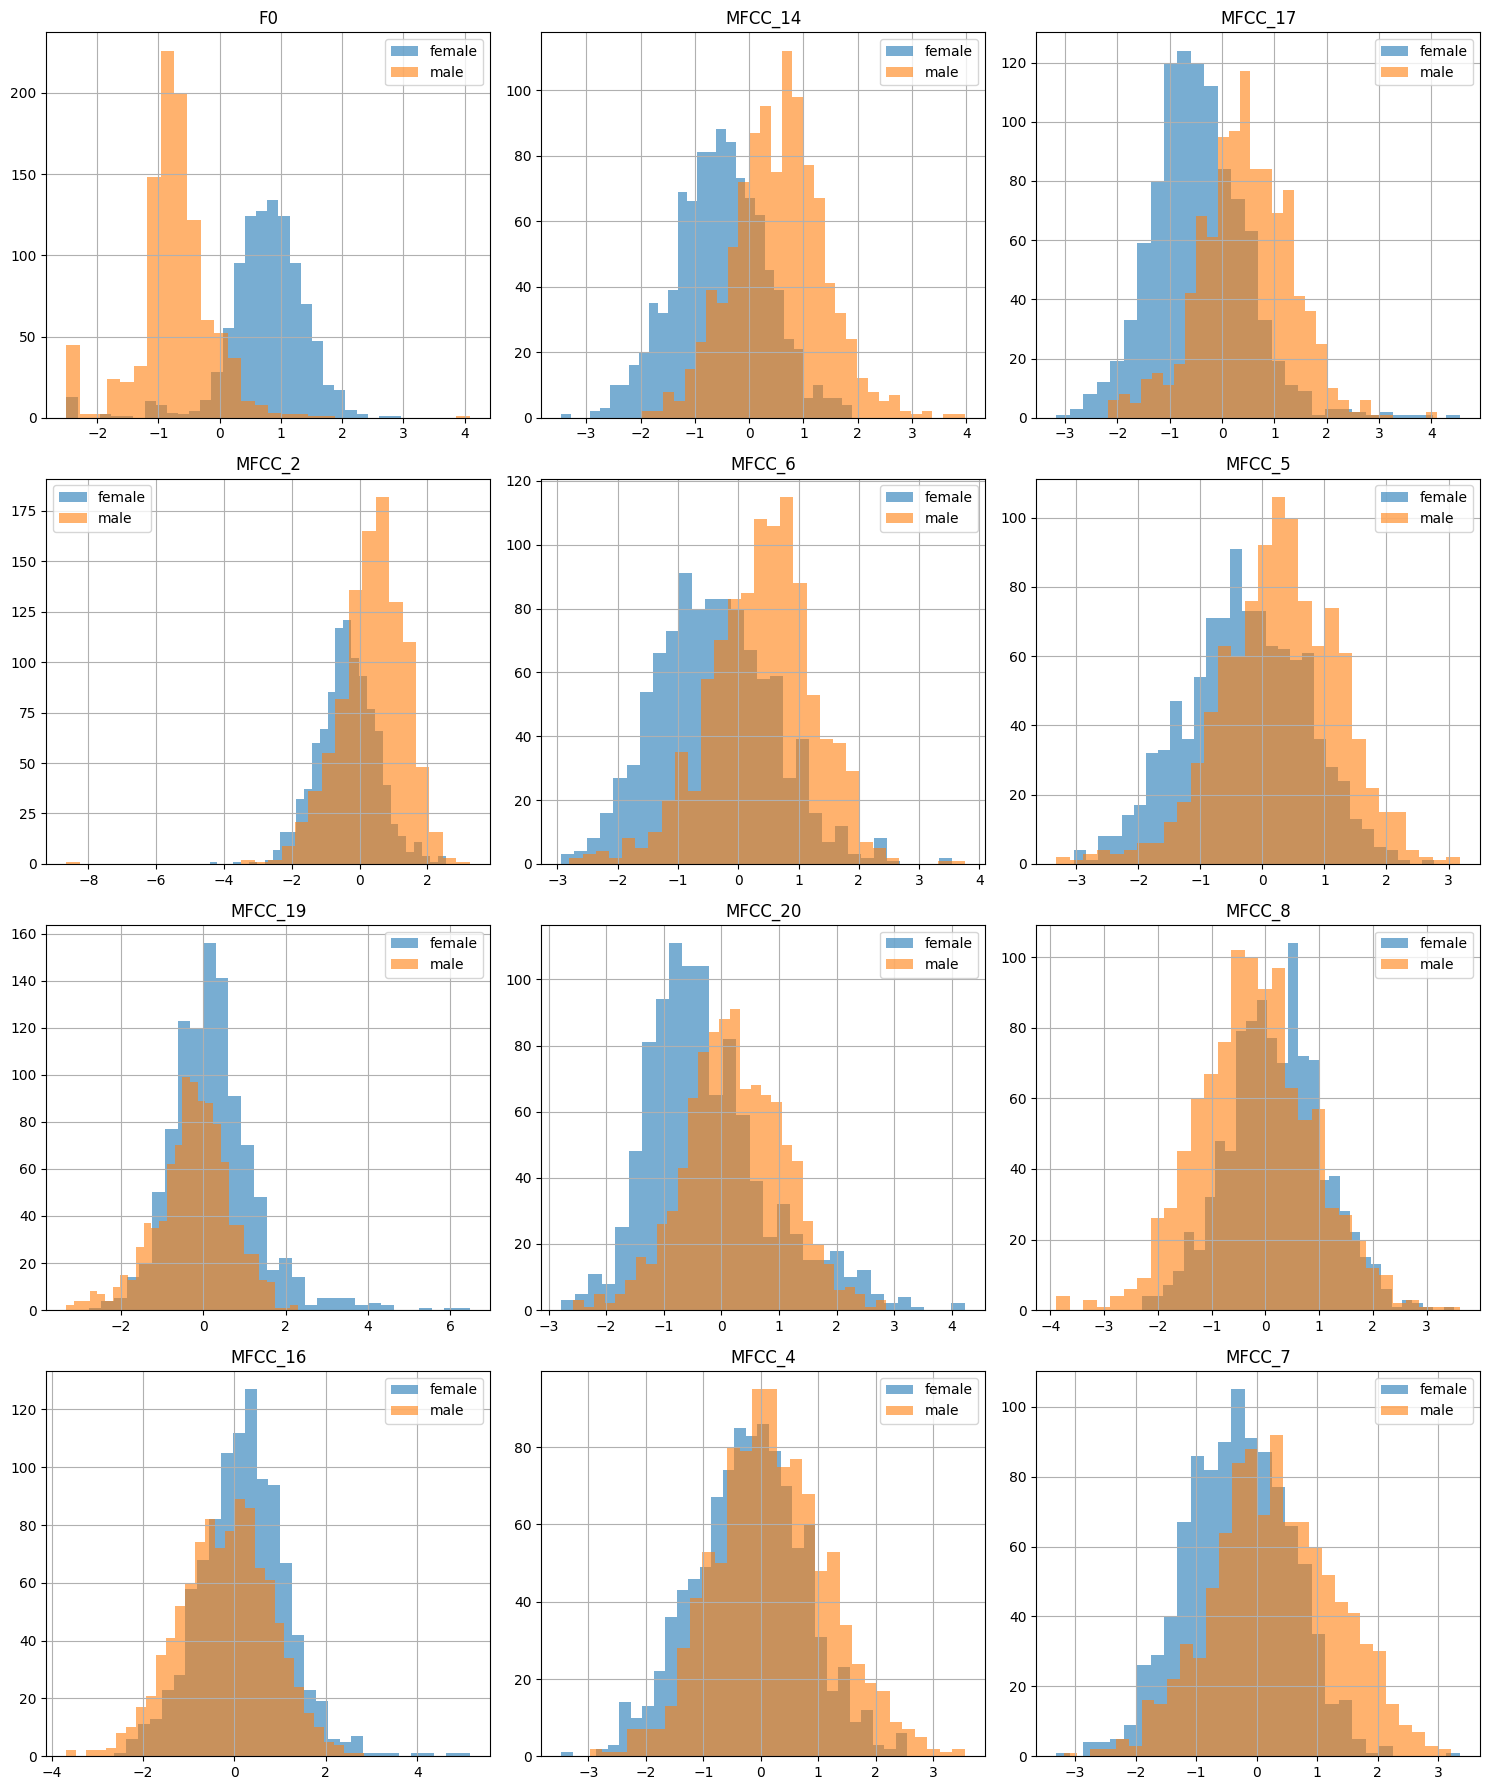

In [10]:
X_train_standardized["Gender"] = y_train.values
num_features = X_train_standardized.shape[1] - 1
fig, axes = plt.subplots(nrows=num_features // 3 , ncols=3, figsize=(15, num_features * 1.5))
axes = axes.flatten()

for i, col in enumerate(X_train_standardized.columns[:-1]):
    X_train_standardized[X_train_standardized["Gender"] == 0][col].hist(alpha=0.6, bins=30, label="female", ax=axes[i])
    X_train_standardized[X_train_standardized["Gender"] == 1][col].hist(alpha=0.6, bins=30, label="male", ax=axes[i])
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

X_train_standardized = X_train_standardized.drop(columns=["Gender"])


### Plotting normalized data

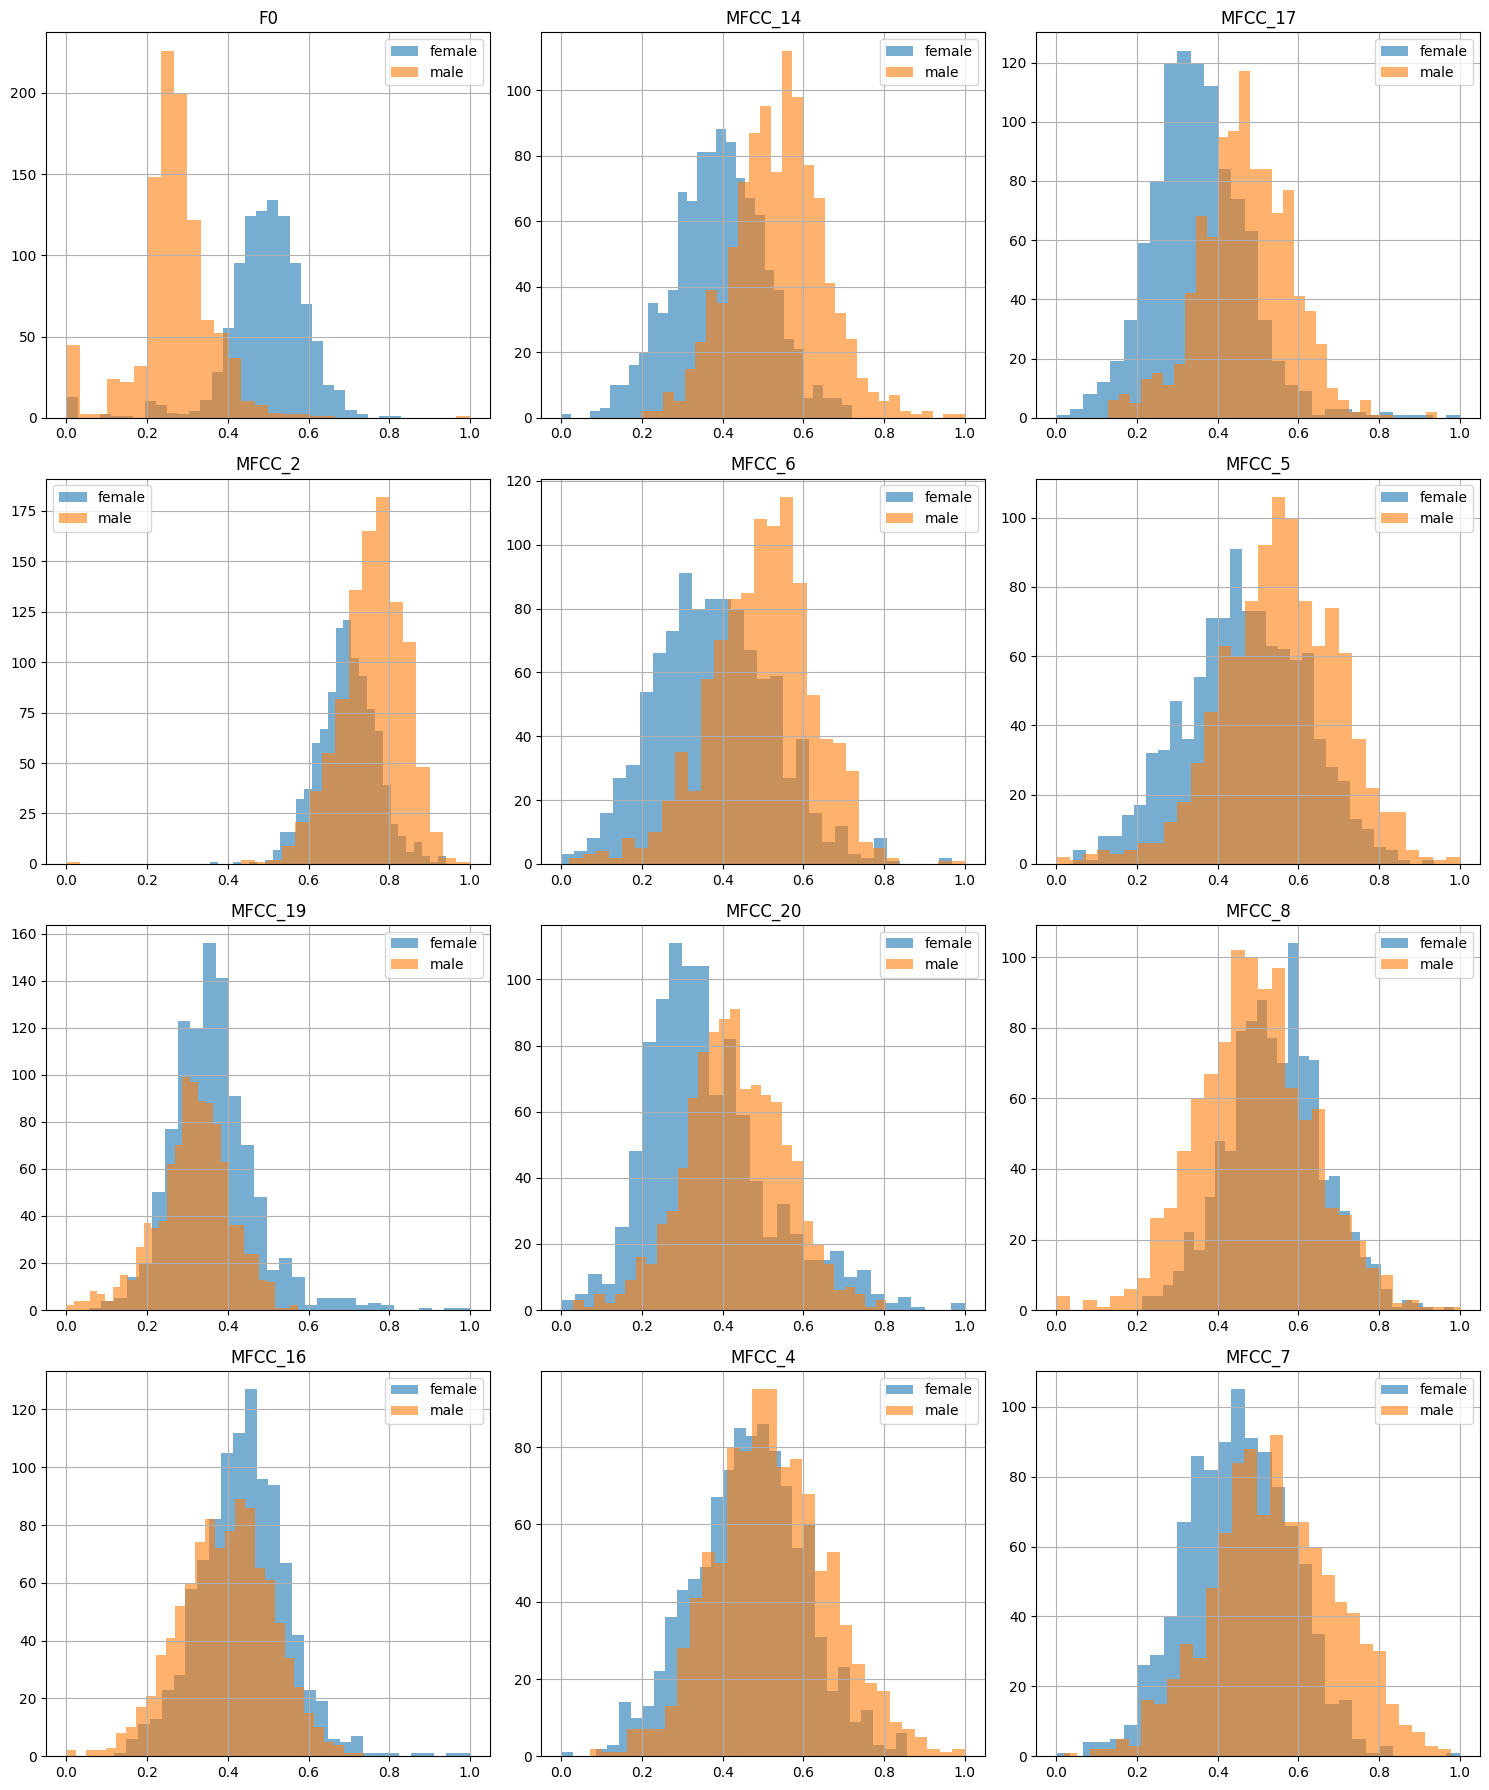

In [11]:
X_train_normalized["Gender"] = y_train.values
num_features = X_train_normalized.shape[1] - 1
fig, axes = plt.subplots(nrows=num_features // 3 , ncols=3, figsize=(15, num_features * 1.5))
axes = axes.flatten()

for i, col in enumerate(X_train_normalized.columns[:-1]):
    X_train_normalized[X_train_normalized["Gender"] == 0][col].hist(alpha=0.6, bins=30, label="female", ax=axes[i])
    X_train_normalized[X_train_normalized["Gender"] == 1][col].hist(alpha=0.6, bins=30, label="male", ax=axes[i])
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

X_train_normalized = X_train_normalized.drop(columns=["Gender"])


## Support Vector Machine (SVM)
We train SVM classifiers with various kernels (`linear`, `rbf`, `poly`, `sigmoid`) to find the best decision boundary.

Confusion Matrix - Normalized - Kernel: linear
[[165  15]
 [  9 171]]
Error Analysis for Normalized - Kernel: linear
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       180
           1       0.92      0.95      0.93       180

    accuracy                           0.93       360
   macro avg       0.93      0.93      0.93       360
weighted avg       0.93      0.93      0.93       360

--------------------------------------------------
Confusion Matrix - Normalized - Kernel: poly
[[170  10]
 [ 10 170]]
Error Analysis for Normalized - Kernel: poly
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       180
           1       0.94      0.94      0.94       180

    accuracy                           0.94       360
   macro avg       0.94      0.94      0.94       360
weighted avg       0.94      0.94      0.94       360

--------------------------------------------------
Confusion Matr

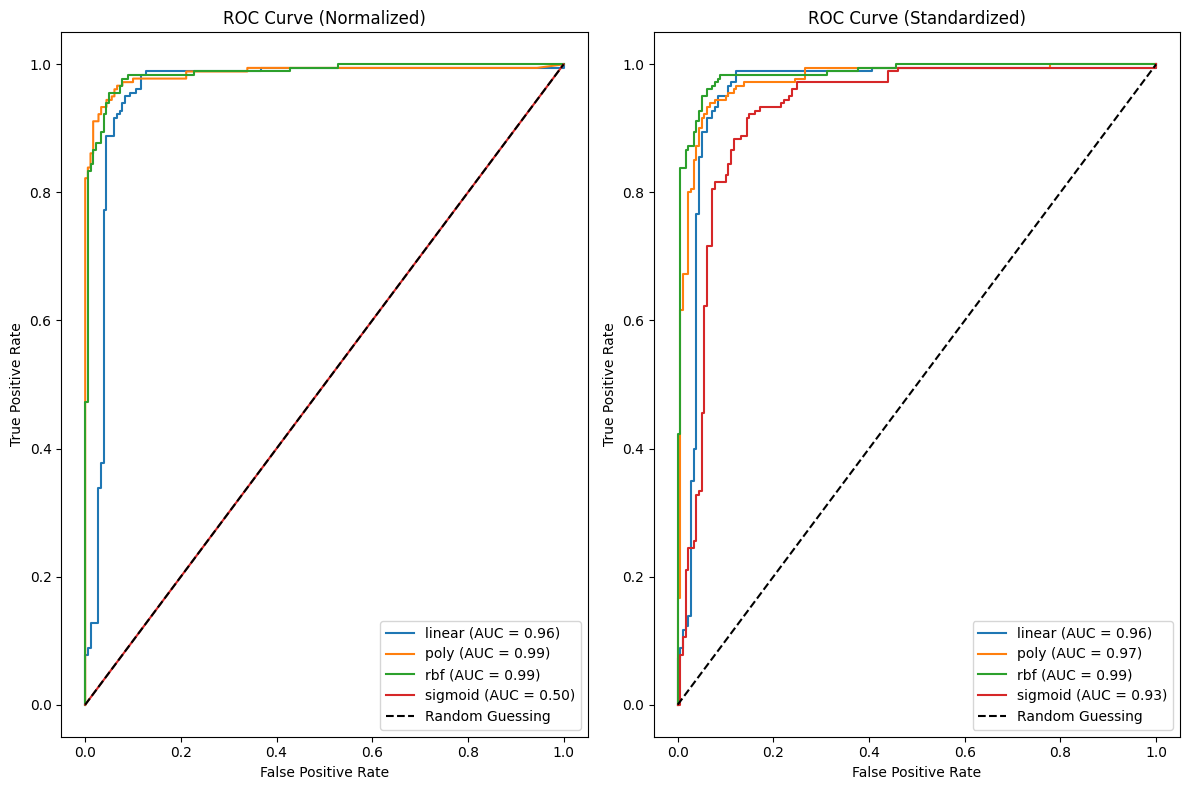

In [ ]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

datasets = {
    "Normalized": (X_train_normalized, X_test_normalized),
    "Standardized": (X_train_standardized, X_test_standardized)
}

plt.figure(figsize=(12, 8))

for data_name, (X_train, X_test) in datasets.items():
    plt.subplot(1, 2, 1 if data_name == "Normalized" else 2)  
    plt.title(f"ROC Curve ({data_name})")
    
    for kernel in kernels:
    
        model = SVC(kernel=kernel, probability=True, random_state=42)
        model.fit(X_train, y_train)
       
        y_score = model.predict_proba(X_test)[:, 1]
        
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
    
        plt.plot(fpr, tpr, label=f'{kernel} (AUC = {roc_auc:.2f})')

        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        
        print(f"Confusion Matrix - {data_name} - Kernel: {kernel}")
        print(cm)
        
        print(f"Error Analysis for {data_name} - Kernel: {kernel}")
        print(classification_report(y_test, y_pred))
        print("-" * 50)

    plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

plt.tight_layout()
plt.show()


## Logistic Regression

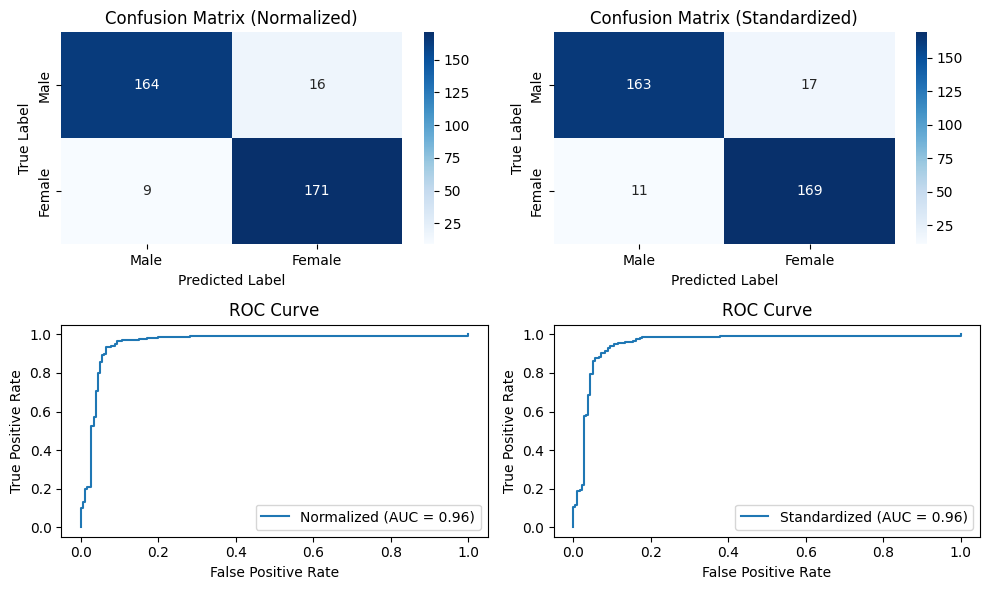


=== Performance Analysis for Normalized ===
Classification Report:
              precision    recall  f1-score     support
0              0.947977  0.911111  0.929178  180.000000
1              0.914439  0.950000  0.931880  180.000000
accuracy       0.930556  0.930556  0.930556    0.930556
macro avg      0.931208  0.930556  0.930529  360.000000
weighted avg   0.931208  0.930556  0.930529  360.000000

Confusion Matrix:
[[164  16]
 [  9 171]]

=== Performance Analysis for Standardized ===
Classification Report:
              precision    recall  f1-score     support
0              0.936782  0.905556  0.920904  180.000000
1              0.908602  0.938889  0.923497  180.000000
accuracy       0.922222  0.922222  0.922222    0.922222
macro avg      0.922692  0.922222  0.922201  360.000000
weighted avg   0.922692  0.922222  0.922201  360.000000

Confusion Matrix:
[[163  17]
 [ 11 169]]


In [ ]:
datasets = {
    "Normalized": (X_train_normalized, X_test_normalized),
    "Standardized": (X_train_standardized, X_test_standardized)
}

results = {}

plt.figure(figsize=(10, 6))

for i, (key, (X_train, X_test)) in enumerate(datasets.items()):

    model = LogisticRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  
    
    cm = confusion_matrix(y_test, y_pred)

    report = classification_report(y_test, y_pred, output_dict=True)
    
    results[key] = {"model": model, "confusion_matrix": cm, "classification_report": report}
    
    plt.subplot(2, 2, i + 1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix ({key})")

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.subplot(2, 2, i + 3)
    plt.plot(fpr, tpr, label=f"{key} (AUC = {roc_auc:.2f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()

plt.tight_layout()
plt.show()

for key, res in results.items():
    print(f"\n=== Performance Analysis for {key} ===")
    print("Classification Report:")
    print(pd.DataFrame(res["classification_report"]).transpose())
    print("\nConfusion Matrix:")
    print(res["confusion_matrix"])


## KNN

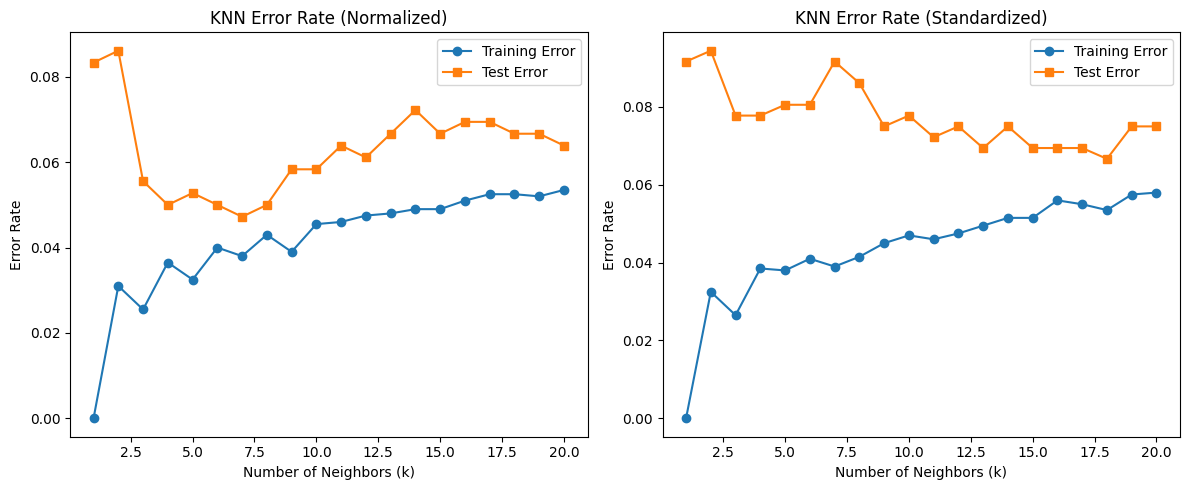

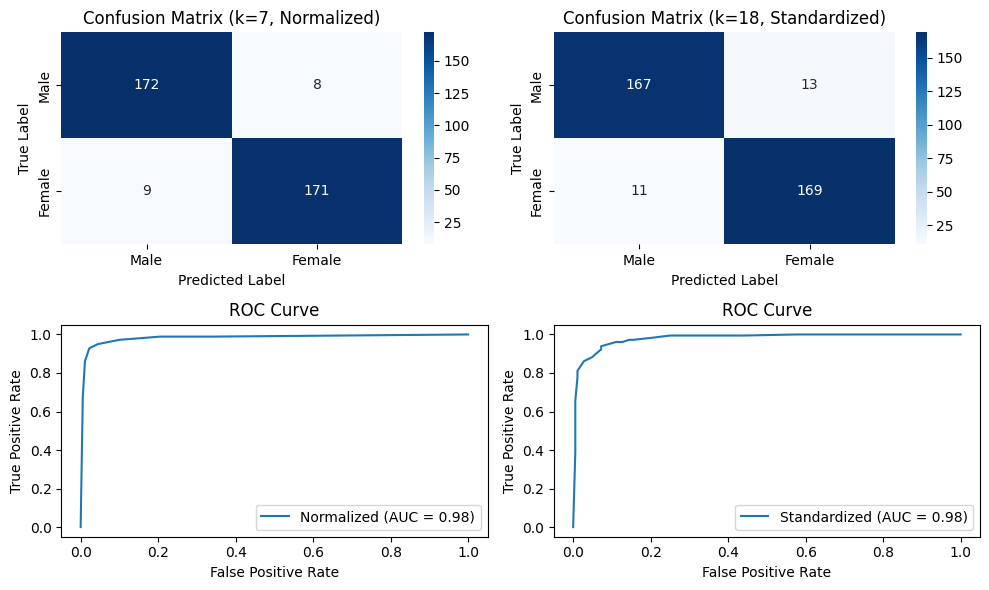


=== Performance Analysis for Normalized (k=7) ===
Classification Report:
              precision    recall  f1-score     support
0              0.950276  0.955556  0.952909  180.000000
1              0.955307  0.950000  0.952646  180.000000
accuracy       0.952778  0.952778  0.952778    0.952778
macro avg      0.952792  0.952778  0.952777  360.000000
weighted avg   0.952792  0.952778  0.952777  360.000000

Confusion Matrix:
[[172   8]
 [  9 171]]

=== Performance Analysis for Standardized (k=18) ===
Classification Report:
              precision    recall  f1-score     support
0              0.938202  0.927778  0.932961  180.000000
1              0.928571  0.938889  0.933702  180.000000
accuracy       0.933333  0.933333  0.933333    0.933333
macro avg      0.933387  0.933333  0.933331  360.000000
weighted avg   0.933387  0.933333  0.933331  360.000000

Confusion Matrix:
[[167  13]
 [ 11 169]]


In [ ]:
k_values = range(1, 21)

datasets = {
    "Normalized": (X_train_normalized, X_test_normalized),
    "Standardized": (X_train_standardized, X_test_standardized)
}


best_k = {}
best_results = {}

plt.figure(figsize=(12, 5))

for i, (key, (X_train, X_test)) in enumerate(datasets.items()):
    train_errors = []
    test_errors = []
    
    for k in k_values:
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train, y_train)
        
        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)
        
        train_errors.append(1 - train_acc)
        test_errors.append(1 - test_acc)

    plt.subplot(1, 2, i + 1)
    plt.plot(k_values, train_errors, label="Training Error", marker='o')
    plt.plot(k_values, test_errors, label="Test Error", marker='s')
    plt.xlabel("Number of Neighbors (k)")
    plt.ylabel("Error Rate")
    plt.title(f"KNN Error Rate ({key})")
    plt.legend()
    
    best_k[key] = k_values[np.argmin(test_errors)]

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

for i, (key, (X_train, X_test)) in enumerate(datasets.items()):
    k_optimal = best_k[key]
    model = KNeighborsClassifier(n_neighbors=k_optimal)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    cm = confusion_matrix(y_test, y_pred)
    
    report = classification_report(y_test, y_pred, output_dict=True)
    
    best_results[key] = {"model": model, "confusion_matrix": cm, "classification_report": report}
    
    plt.subplot(2, 2, i + 1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix (k={k_optimal}, {key})")

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.subplot(2, 2, i + 3)
    plt.plot(fpr, tpr, label=f"{key} (AUC = {roc_auc:.2f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()

plt.tight_layout()
plt.show()

for key, res in best_results.items():
    print(f"\n=== Performance Analysis for {key} (k={best_k[key]}) ===")
    print("Classification Report:")
    print(pd.DataFrame(res["classification_report"]).transpose())
    print("\nConfusion Matrix:")
    print(res["confusion_matrix"])


## MLP
Finally, we implement a custom **Multi-Layer Perceptron (MLP)** using PyTorch. The architecture consists of 3 fully connected layers with ReLU activation and Dropout for regularization.

Using device: cuda
Epoch 1/20 - Train Loss: 0.6227, Train Acc: 0.7095, Test Loss: 0.4773, Test Acc: 0.8889
Epoch 2/20 - Train Loss: 0.3496, Train Acc: 0.8870, Test Loss: 0.2743, Test Acc: 0.9167
Epoch 3/20 - Train Loss: 0.2631, Train Acc: 0.9010, Test Loss: 0.2412, Test Acc: 0.9278
Epoch 4/20 - Train Loss: 0.2511, Train Acc: 0.9080, Test Loss: 0.2411, Test Acc: 0.9250
Epoch 5/20 - Train Loss: 0.2293, Train Acc: 0.9185, Test Loss: 0.2278, Test Acc: 0.9333
Epoch 6/20 - Train Loss: 0.2178, Train Acc: 0.9180, Test Loss: 0.2286, Test Acc: 0.9250
Epoch 7/20 - Train Loss: 0.2157, Train Acc: 0.9225, Test Loss: 0.2359, Test Acc: 0.9278
Epoch 8/20 - Train Loss: 0.2086, Train Acc: 0.9260, Test Loss: 0.2253, Test Acc: 0.9278
Epoch 9/20 - Train Loss: 0.2102, Train Acc: 0.9280, Test Loss: 0.2313, Test Acc: 0.9306
Epoch 10/20 - Train Loss: 0.2078, Train Acc: 0.9220, Test Loss: 0.2249, Test Acc: 0.9222
Epoch 11/20 - Train Loss: 0.2059, Train Acc: 0.9300, Test Loss: 0.2184, Test Acc: 0.9306
Epoch 12/20

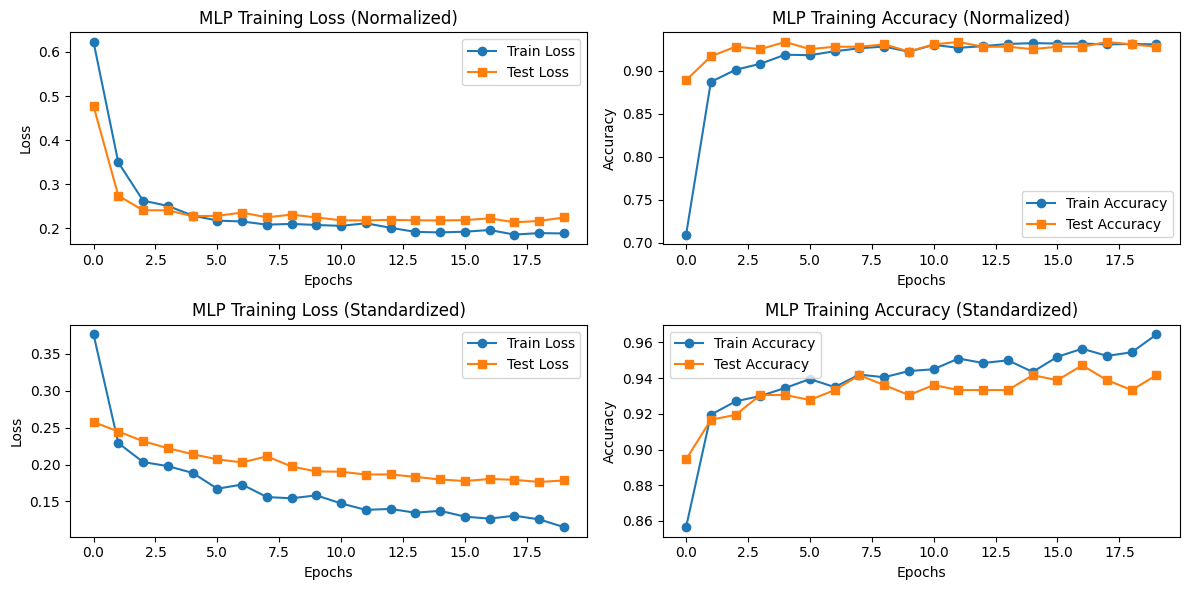

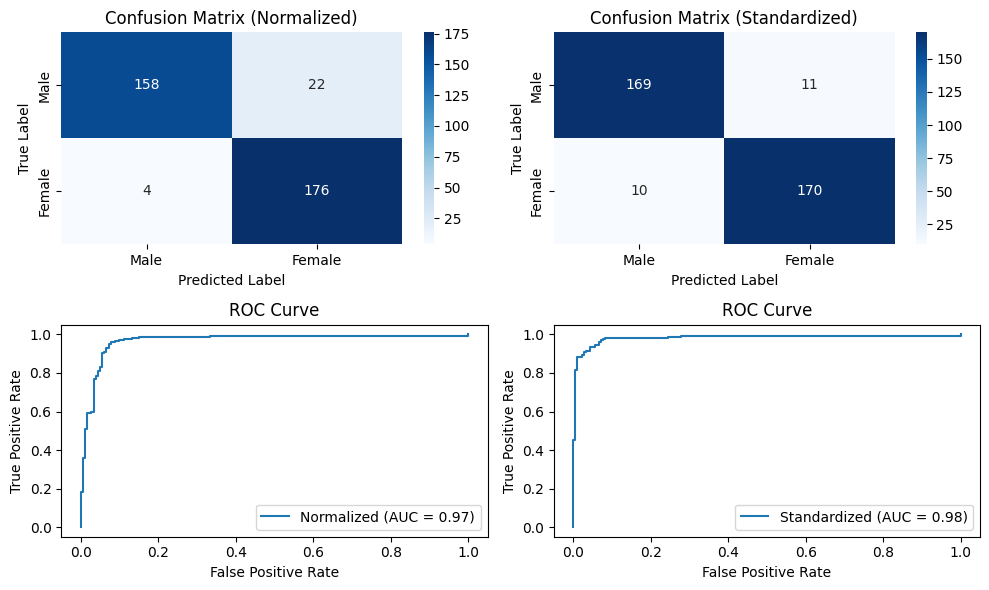

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def prepare_data(X_train, X_test, y_train, y_test):
    X_train = X_train.to_numpy() if isinstance(X_train, pd.DataFrame) else X_train
    X_test = X_test.to_numpy() if isinstance(X_test, pd.DataFrame) else X_test
    y_train = y_train.to_numpy() if isinstance(y_train, pd.Series) else y_train
    y_test = y_test.to_numpy() if isinstance(y_test, pd.Series) else y_test

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    return train_loader, test_loader

datasets = {
    "Normalized": prepare_data(X_train_normalized, X_test_normalized, y_train, y_test),
    "Standardized": prepare_data(X_train_standardized, X_test_standardized, y_train, y_test)
}


class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 2)  
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

def train_model(model, train_loader, test_loader, epochs=20, lr=0.001):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, test_losses = [], []
    train_accuracies, test_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss = running_loss / len(train_loader)
        train_accuracy = correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        model.eval()
        test_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                test_loss += loss.item()
                predictions = torch.argmax(outputs, dim=1)
                correct += (predictions == y_batch).sum().item()
                total += y_batch.size(0)

        test_losses.append(test_loss / len(test_loader))
        test_accuracies.append(correct / total)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, Test Loss: {test_losses[-1]:.4f}, Test Acc: {test_accuracies[-1]:.4f}")

    return train_losses, test_losses, train_accuracies, test_accuracies

best_results = {}

plt.figure(figsize=(12, 6))

for i, (key, (train_loader, test_loader)) in enumerate(datasets.items()):
    input_size = next(iter(train_loader))[0].shape[1]

    model = MLP(input_size)
    

    train_losses, test_losses, train_accuracies, test_accuracies = train_model(model, train_loader, test_loader, epochs=20, lr=0.001)


    plt.subplot(2, 2, i * 2 + 1)
    plt.plot(train_losses, label="Train Loss", marker='o')
    plt.plot(test_losses, label="Test Loss", marker='s')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"MLP Training Loss ({key})")
    plt.legend()
    
    plt.subplot(2, 2, i * 2 + 2)
    plt.plot(train_accuracies, label="Train Accuracy", marker='o')
    plt.plot(test_accuracies, label="Test Accuracy", marker='s')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title(f"MLP Training Accuracy ({key})")
    plt.legend()
    
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            probabilities = torch.softmax(outputs, dim=1)[:, 1]
            predictions = torch.argmax(outputs, dim=1)

            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())
            y_prob.extend(probabilities.cpu().numpy())


    final_accuracy = accuracy_score(y_true, y_pred)
    print(f"Final Test Accuracy for {key}: {final_accuracy:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True)

    best_results[key] = {"model": model, "confusion_matrix": cm, "classification_report": report, "y_true": y_true, "y_prob": y_prob}

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

for i, (key, res) in enumerate(best_results.items()):
    plt.subplot(2, 2, i + 1)
    sns.heatmap(res["confusion_matrix"], annot=True, fmt="d", cmap="Blues", xticklabels=["Male", "Female"], yticklabels=["Male", "Female"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix ({key})")

    fpr, tpr, _ = roc_curve(res["y_true"], res["y_prob"])
    roc_auc = auc(fpr, tpr)
    plt.subplot(2, 2, i + 3)
    plt.plot(fpr, tpr, label=f"{key} (AUC = {roc_auc:.2f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()

plt.tight_layout()
plt.show()
